# 3. Comparación de modelos y adaptación temporal

## Resumen y propósito
Comparamos LightGBM, XGBoost y CatBoost en bloques futuros con modelo estático, actualización semanal y actualización por alerta. Para cada modelo se prueban ventanas de 14, 30 y 45 días y un historial acumulado. Regresión logística y árbol de decisión son referencias tradicionales. Las cifras se completan con los outputs ejecutados.

## Protocolo temporal y controles
Split original 70/15/15; bloques de siete días, marcando el último parcial. La primera semana de validación es calentamiento para permitir el supuesto de **siete días de latencia de etiqueta**. Antes de un bloque que empieza en `t`, el entrenamiento solo usa filas anteriores a `t−7 días`. El conjunto de 185 variables se fija en el train inicial; cuartiles y codificaciones se reajustan con cada ventana pasada.

In [1]:
import json, os
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

FINAL_ROOT = Path.cwd() if (Path.cwd() / 'v01_features.json').exists() else Path.cwd() / 'final'
__file__ = str(FINAL_ROOT / 'common.py')
V01_FEATURES = ['V258', 'C5', 'D1n', 'D3', 'C13', 'C1', 'C14', 'card1', 'D2n', 'card2', 'TransactionAmt', 'D15n', 'addr1', 'D2', 'D10n', 'C11', 'card6_label', 'P_emaildomain_label', 'C6', 'card5', 'D4', 'M4_freq', 'V257', 'D15', 'C2', 'C8', 'dist1', 'card3', 'card6_freq', 'C9', 'P_emaildomain_freq', 'D8', 'M4_label', 'M5_label', 'D1', 'D10', 'C10', 'M5_freq', 'id_02', 'C4', 'DT_hour', 'ProductCD_label', 'R_emaildomain_label', 'V189', 'V45', 'V243', 'D5', 'M6_freq', 'DeviceInfo_label', 'id_20', 'TransactionAmt_log1p', 'D11', 'id_01', 'C12', 'V87', 'DeviceInfo_freq', 'V78', 'V201', 'id_19', 'id_13', 'V140', 'ProductCD_freq', 'missing_D_count', 'V262', 'id_05', 'V38', 'M6_label', 'card4_label', 'dist2', 'V156', 'id_14', 'id_06', 'M3_label', 'missing_V_count', 'R_emaildomain_freq', 'V149', 'id_17', 'card4_freq', 'V94', 'D13', 'V37', 'id_18', 'DeviceType_freq', 'V74', 'D6', 'id_32', 'V58', 'D14', 'id_09', 'D9', 'D12', 'V86', 'addr2', 'C7', 'C3', 'V64', 'V170', 'id_03', 'D7', 'V44', 'V47', 'V217', 'missing_core_count', 'V52', 'V23', 'TransactionAmt_outlier_iqr', 'V79', 'M3_freq', 'V148', 'V157', 'M2_label', 'V33', 'V171', 'M9_label', 'M7_label', 'missing_id_count', 'V57', 'V219', 'V81', 'V39', 'M8_label', 'V154', 'V199', 'M9_freq', 'V232', 'V63', 'V34', 'V177', 'id_11', 'V228', 'V233', 'V230', 'V40', 'V158', 'V146', 'V231', 'id_04', 'V60', 'V155', 'V200', 'V51', 'V188', 'id_24', 'V190', 'DeviceType_label', 'V50', 'M8_freq', 'V85', 'V252', 'V73', 'M2_freq', 'id_21', 'V147', 'V197', 'V153', 'M7_freq', 'V16', 'V72', 'V84', 'V246', 'V43', 'V15', 'id_08', 'id_26', 'id_25', 'V244', 'id_07', 'V247', 'M1_freq', 'V93', 'V42', 'V71', 'V18', 'V242', 'V92', 'V32', 'id_10', 'V80', 'M1_label', 'V21', 'V17', 'V22', 'V31', 'has_identity', 'id_22']
RUN_FULL = (os.name == 'posix' and Path('/kaggle/working').exists()) or os.getenv('PTDIA_RUN_FULL') == '1'
print('Ejecución completa:', RUN_FULL)

Ejecución completa: False


### Implementación reproducible
Las funciones siguientes son código ejecutable del proyecto. Se agrupan por responsabilidad y se pueden ejecutar de arriba abajo sin archivos auxiliares.

In [2]:
"""Shared, deterministic IEEE-CIS helpers for the four final notebooks.

The notebook entry points call these functions. Nothing is fitted on future
rows: a preprocessing instance is created for each historical training window.
"""

from __future__ import annotations

import gc
import gzip
import json
import os
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import average_precision_score, precision_score, recall_score

DAY = 86400
WEEK = 7 * DAY
SEED = 42
CAT_COLS = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo"] + [f"M{i}" for i in range(1, 10)]
MONITOR_COLS = ["TransactionAmt", "D1n", "D2n", "D10n", "D15n", "C9", "id_02", "id_20", "D11", "id_01"]


def paths(stage: str):
    here = Path(__file__).resolve().parent
    candidates = [
        Path("/kaggle/input/ieee-fraud-detection"),
        Path("/kaggle/input/competitions/ieee-fraud-detection"),
        here.parent / "ieee-fraud-detection",
    ]
    data = next((p for p in candidates if (p / "train_transaction.csv").exists()), None)
    if data is None:
        raise FileNotFoundError("IEEE-CIS competition input unavailable")
    output = Path("/kaggle/working") if os.name == "posix" and Path("/kaggle/working").exists() else here / "kaggle" / stage / "outputs"
    output.mkdir(parents=True, exist_ok=True)
    (output / "plots").mkdir(exist_ok=True)
    return data, output


def manifest(output: Path, **values):
    target = output / "run_summary.json"
    current = json.loads(target.read_text()) if target.exists() else {}
    current.update(values)
    target.write_text(json.dumps(current, indent=2, default=float), encoding="utf-8")


def save_plot(output: Path, name: str):
    plt.tight_layout()
    plt.savefig(output / "plots" / name, dpi=140, bbox_inches="tight")
    plt.close()


def load_data(data: Path, include_test: bool = False):
    def one(prefix: str):
        txn = pd.read_csv(data / f"{prefix}_transaction.csv", low_memory=False)
        identity = pd.read_csv(data / f"{prefix}_identity.csv", low_memory=False)
        # IEEE-CIS test identity uses id-01 style names, while train uses id_01.
        identity.rename(columns=lambda c: c.replace("id-", "id_") if c.startswith("id-") else c, inplace=True)
        if txn.TransactionID.duplicated().any() or identity.TransactionID.duplicated().any():
            raise ValueError("TransactionID must be unique in each source")
        out = txn.merge(identity, on="TransactionID", how="left", validate="one_to_one", indicator="_identity_join")
        del txn, identity
        gc.collect()
        out["has_identity_join"] = out["_identity_join"].eq("both").astype("int8")
        out.drop(columns="_identity_join", inplace=True)
        out.sort_values(["TransactionDT", "TransactionID"], inplace=True)
        out.reset_index(drop=True, inplace=True)
        return out

    train = one("train")
    test = one("test") if include_test else None
    return train, test


def split_bounds(df: pd.DataFrame):
    return float(df.TransactionDT.quantile(0.70)), float(df.TransactionDT.quantile(0.85))


def split_name(dt: pd.Series, bounds: tuple[float, float]):
    return np.where(dt <= bounds[0], "train", np.where(dt <= bounds[1], "valid", "holdout"))


def row_features(df: pd.DataFrame):
    """Only own-row information. Fitted statistics are added by WindowEncoder."""
    out = df.copy()
    day = (out.TransactionDT // DAY).astype("int16")
    out["DT_hour"] = ((out.TransactionDT // 3600) % 24).astype("int8")
    out["DT_day_index"] = day
    out["DT_week_index"] = (day // 7).astype("int16")
    out["has_identity"] = out["has_identity_join"].astype("int8")
    out["TransactionAmt_log1p"] = np.log1p(out.TransactionAmt.clip(lower=0)).astype("float32")
    for family in ("V", "D", "id_"):
        cols = [c for c in out if c.startswith(family) and (family == "id_" or c[len(family):].isdigit())]
        out[f"missing_{family.replace('_', '')}_count"] = out[cols].isna().sum(axis=1).astype("int16") if cols else 0
    core = [c for c in ["card2", "card3", "card5", "addr1", "addr2", "dist1", "dist2"] if c in out]
    out["missing_core_count"] = out[core].isna().sum(axis=1).astype("int8")
    for col in ["D1", "D2", "D10", "D15"]:
        out[f"{col}n"] = (out[col] - day).astype("float32")
    return out


def candidate_uid(df: pd.DataFrame):
    parts = df[["card1", "card2", "card3", "card5", "addr1", "addr2"]].astype("string").fillna("NA")
    parts = parts.copy()
    parts["D1_anchor"] = (df.D1 - df.TransactionDT // DAY).round(0).astype("string").fillna("NA")
    return pd.util.hash_pandas_object(parts, index=False).astype("uint64")

In [3]:
def feature_list():
    here = Path(__file__).resolve().parent
    for path in (here / "v01_features.json", here / "input" / "v01_features.json"):
        if path.exists():
            return json.loads(path.read_text(encoding="utf-8"))
    if "V01_FEATURES" in globals():
        return list(globals()["V01_FEATURES"])
    raise FileNotFoundError("v01_features.json is required")


@dataclass
class WindowEncoder:
    features: list[str]
    q_low: float = 0.0
    q_high: float = 0.0
    maps: dict | None = None
    freqs: dict | None = None

    def fit(self, train: pd.DataFrame):
        q1, q3 = train.TransactionAmt.quantile([.25, .75])
        self.q_low, self.q_high = float(q1 - 1.5 * (q3 - q1)), float(q3 + 1.5 * (q3 - q1))
        self.maps, self.freqs = {}, {}
        for col in CAT_COLS:
            if col not in train:
                continue
            s = train[col].astype("string").fillna("__MISSING__")
            self.maps[col] = {v: i for i, v in enumerate(s.unique())}
            self.freqs[col] = (s.value_counts(dropna=False) / len(s)).to_dict()
        return self

    def transform(self, rows: pd.DataFrame):
        cols = {}
        for name in self.features:
            if name == "TransactionAmt_outlier_iqr":
                cols[name] = ((rows.TransactionAmt < self.q_low) | (rows.TransactionAmt > self.q_high)).astype("float32")
            elif name.endswith("_label") and name[:-6] in self.maps:
                col = name[:-6]
                cols[name] = rows[col].astype("string").fillna("__MISSING__").map(self.maps[col]).fillna(-1).astype("float32")
            elif name.endswith("_freq") and name[:-5] in self.freqs:
                col = name[:-5]
                cols[name] = rows[col].astype("string").fillna("__MISSING__").map(self.freqs[col]).fillna(0).astype("float32")
            elif name in rows:
                cols[name] = pd.to_numeric(rows[name], errors="coerce").astype("float32")
            else:
                cols[name] = pd.Series(np.nan, index=rows.index, dtype="float32")
        return pd.DataFrame(cols, index=rows.index).replace([np.inf, -np.inf], np.nan)


def psi(reference, current, bins=10):
    a = np.asarray(reference, dtype=float)
    b = np.asarray(current, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 100 or len(b) < 100:
        return np.nan
    edges = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0 if np.isclose(np.mean(a), np.mean(b)) else np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    pa = np.clip(np.histogram(a, edges)[0] / len(a), 1e-6, 1)
    pb = np.clip(np.histogram(b, edges)[0] / len(b), 1e-6, 1)
    return float(np.sum((pb - pa) * np.log(pb / pa)))


def safe_ap(y, pred):
    return float(average_precision_score(y, pred)) if len(y) and len(np.unique(y)) == 2 else np.nan


def evaluation_blocks(df: pd.DataFrame, bounds: tuple[float, float]):
    """Seven-day blocks clipped to each split; first valid week is label warm-up."""
    blocks = []
    for split, start, end in (("valid", bounds[0], bounds[1]), ("holdout", bounds[1], float(df.TransactionDT.max()) + 1)):
        index = 0
        t = start
        while t < end:
            u = min(t + WEEK, end)
            # First validation week warms up the seven-day label delay.
            if not (split == "valid" and index == 0):
                mask = (df.TransactionDT > t) & (df.TransactionDT <= u) if split == "valid" else (df.TransactionDT > t) & (df.TransactionDT < u)
                ix = df.index[mask].to_numpy()
                if len(ix):
                    blocks.append({"split": split, "block": index, "start": t, "end": u, "partial": u - t < WEEK, "indices": ix})
            t = u
            index += 1
    return blocks


def prediction_rows(df: pd.DataFrame, ix, uid_known, pred, model, strategy, window_days, block):
    return pd.DataFrame({
        "TransactionID": df.loc[ix, "TransactionID"].to_numpy(),
        "TransactionDT": df.loc[ix, "TransactionDT"].to_numpy(),
        "TransactionAmt": df.loc[ix, "TransactionAmt"].to_numpy(),
        "isFraud": df.loc[ix, "isFraud"].to_numpy(),
        "uid_known": uid_known,
        "score": np.asarray(pred),
        "model": model,
        "strategy": strategy,
        "window_days": window_days,
        "split": block["split"],
        "block": block["block"],
    })


def append_predictions(output: Path, rows: pd.DataFrame):
    path = output / "predictions.csv.gz"
    rows.to_csv(path, mode="at" if path.exists() else "wt", index=False, header=not path.exists(), compression="gzip")


def quick_cost(y, amount, score, review_fraction=.05, review_effectiveness=.8):
    """Offline same-capacity ranking proxy; operational queue is in policy notebook."""
    n = len(score)
    k = max(1, int(n * review_fraction))
    review = np.zeros(n, dtype=bool)
    review[np.argsort(score)[-k:]] = True
    loss = 4.41 * np.asarray(amount) * np.asarray(y)
    total = float(np.sum(np.where(review, 2 + (1 - review_effectiveness) * loss, loss)))
    return total / max(n, 1), float(recall_score(y, review, zero_division=0)), float(precision_score(y, review, zero_division=0))


def block_metrics(rows: pd.DataFrame, seconds=0.0, updated=False, device="none", psi_score=np.nan):
    y = rows.isFraud.to_numpy(dtype=int)
    p = rows.score.to_numpy(dtype=float)
    cost, recall, precision = quick_cost(y, rows.TransactionAmt, p)
    return {
        "model": rows.model.iloc[0], "strategy": rows.strategy.iloc[0], "window_days": rows.window_days.iloc[0],
        "split": rows.split.iloc[0], "block": int(rows.block.iloc[0]), "rows": len(rows),
        "fraud_rate": float(np.mean(y)), "pr_auc": safe_ap(y, p), "recall_at_5pct": recall,
        "precision_at_5pct": precision, "cost_per_txn_proxy": cost,
        "uid_known_pr_auc": safe_ap(y[rows.uid_known.to_numpy(dtype=bool)], p[rows.uid_known.to_numpy(dtype=bool)]),
        "uid_unknown_pr_auc": safe_ap(y[~rows.uid_known.to_numpy(dtype=bool)], p[~rows.uid_known.to_numpy(dtype=bool)]),
        "train_seconds": seconds, "updated": int(updated), "device": device, "psi_score": psi_score,
    }

In [4]:
def _v01_predictions():
    here = Path(__file__).resolve().parent
    candidates = [here / "v01_reference", here.parent / "03_outputs" / "v01_baseline_temporal"]
    candidates += list(Path("/kaggle/input").glob("**/baseline_valid_predictions.csv")) if Path("/kaggle/input").exists() else []
    for path in candidates:
        folder = path if path.is_dir() else path.parent
        a, b = folder / "baseline_valid_predictions.csv", folder / "baseline_holdout_predictions.csv"
        if a.exists() and b.exists():
            return pd.concat([pd.read_csv(a), pd.read_csv(b)], ignore_index=True)
    return None



def make_model(name: str, device: str, positive_weight: float):
    if name == "lightgbm":
        import lightgbm as lgb
        return lgb.LGBMClassifier(
            objective="binary", n_estimators=220, learning_rate=.05, num_leaves=48,
            min_child_samples=120, subsample=.85, colsample_bytree=.75,
            reg_alpha=.05, reg_lambda=.20, class_weight="balanced",
            random_state=SEED, n_jobs=4, verbosity=-1,
            device_type="gpu" if device == "gpu" else "cpu",
        )
    if name == "xgboost":
        from xgboost import XGBClassifier
        return XGBClassifier(
            n_estimators=160, learning_rate=.05, max_depth=6, min_child_weight=20,
            subsample=.85, colsample_bytree=.8, reg_lambda=1.0,
            objective="binary:logistic", eval_metric="aucpr", tree_method="hist",
            device="cuda" if device == "gpu" else "cpu", n_jobs=4,
            scale_pos_weight=positive_weight, random_state=SEED,
        )
    if name == "catboost":
        from catboost import CatBoostClassifier
        return CatBoostClassifier(
            iterations=160, learning_rate=.05, depth=7, l2_leaf_reg=8,
            loss_function="Logloss", auto_class_weights="Balanced",
            task_type="GPU" if device == "gpu" else "CPU", devices="0" if device == "gpu" else None,
            random_seed=SEED, verbose=False, allow_writing_files=False,
        )
    raise ValueError(name)


def fit_model(name: str, x_train, y_train):
    weight = float((y_train == 0).sum() / max(int((y_train == 1).sum()), 1))
    start = time.perf_counter()
    error = None
    devices = ("gpu", "cpu") if (os.name == "nt" or Path("/dev/nvidia0").exists()) else ("cpu",)
    for device in devices:
        try:
            model = make_model(name, device, weight)
            model.fit(x_train, y_train)
            return model, device, time.perf_counter() - start, error
        except Exception as exc:
            if device == "cpu":
                raise
            error = f"{type(exc).__name__}: {str(exc)[:300]}"
            gc.collect()
    raise RuntimeError("unreachable")


def model_snapshot(df: pd.DataFrame, train_ix, features: list[str], name: str):
    encoder = WindowEncoder(features).fit(df.loc[train_ix])
    x_train = encoder.transform(df.loc[train_ix])
    y_train = df.loc[train_ix, "isFraud"].to_numpy(dtype=np.int8)
    model, device, seconds, fallback = fit_model(name, x_train, y_train)
    del x_train
    gc.collect()
    return {"encoder": encoder, "model": model, "device": device, "seconds": seconds, "fallback": fallback,
            "rows": len(train_ix), "first_dt": float(df.loc[train_ix, "TransactionDT"].min()),
            "last_dt": float(df.loc[train_ix, "TransactionDT"].max())}


def predict_snapshot(snapshot, df: pd.DataFrame, ix):
    x = snapshot["encoder"].transform(df.loc[ix])
    p = snapshot["model"].predict_proba(x)[:, 1]
    del x
    return np.asarray(p, dtype="float32")


def traditional_baselines(df: pd.DataFrame, bounds, features, out):
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.tree import DecisionTreeClassifier

    train_ix = df.index[df.TransactionDT <= bounds[0]]
    valid_ix = df.index[(df.TransactionDT > bounds[0]) & (df.TransactionDT <= bounds[1])]
    hold_ix = df.index[df.TransactionDT > bounds[1]]
    encoder = WindowEncoder(features).fit(df.loc[train_ix])
    xtr = encoder.transform(df.loc[train_ix])
    xva = encoder.transform(df.loc[valid_ix])
    xho = encoder.transform(df.loc[hold_ix])
    ytr = df.loc[train_ix, "isFraud"].to_numpy(dtype=int)
    rows = []
    for name, estimator in (
        ("regresion_logistica", make_pipeline(SimpleImputer(strategy="median", keep_empty_features=True),
                                              StandardScaler(), LogisticRegression(max_iter=120, class_weight="balanced", solver="saga", random_state=SEED, n_jobs=4))),
        ("arbol_decision", make_pipeline(SimpleImputer(strategy="median", keep_empty_features=True),
                                         DecisionTreeClassifier(max_depth=8, min_samples_leaf=120, class_weight="balanced", random_state=SEED))),
    ):
        start = time.perf_counter()
        estimator.fit(xtr, ytr)
        seconds = time.perf_counter() - start
        for split, ix, x in (("valid", valid_ix, xva), ("holdout", hold_ix, xho)):
            pred = estimator.predict_proba(x)[:, 1]
            rows.append({"model": name, "split": split, "rows": len(ix),
                         "pr_auc": safe_ap(df.loc[ix, "isFraud"], pred), "train_seconds": seconds})
    result = pd.DataFrame(rows)
    result.to_csv(out / "traditional_baselines.csv", index=False)
    return result


def _known_before(uid: pd.Series, dt: pd.Series, start: float, ix):
    historical = set(uid.loc[dt < start].to_numpy())
    return uid.loc[ix].isin(historical).to_numpy(dtype=bool)


def _eligible_indices(df: pd.DataFrame, block, window_days):
    cutoff = block["start"] - WEEK
    floor = -np.inf if window_days == "expanding" else cutoff - int(window_days) * DAY
    ix = df.index[(df.TransactionDT < cutoff) & (df.TransactionDT >= floor)].to_numpy()
    if len(ix) < 3000 or df.loc[ix, "isFraud"].sum() < 20:
        raise ValueError(f"Insufficient historical labels for {window_days} days at {block['start']}")
    if float(df.loc[ix, "TransactionDT"].max()) >= cutoff:
        raise AssertionError("Label latency violated")
    return ix

In [5]:
def _triggered(history: list[dict], current_start: float, reference_ap: float, last_update_number: int, block_number: int):
    if block_number - last_update_number < 2 or not history:
        return False, "cooldown_or_first_block"
    # PSI needs no labels, but uses only the PREVIOUS completed block.
    if np.isfinite(history[-1]["psi_score"]) and history[-1]["psi_score"] > .25:
        return True, "previous_score_psi_gt_025"
    matured = [h for h in history if h["end"] <= current_start - WEEK and np.isfinite(h["pr_auc"])]
    if len(matured) >= 2 and np.isfinite(reference_ap):
        if all(h["pr_auc"] < .9 * reference_ap for h in matured[-2:]):
            return True, "two_matured_pr_auc_drops_gt_10pct"
    return False, "no_alert"

In [6]:
def run_models():
    data, out = paths("experimentacion")
    manifest(out, status="running", stage="load", label_delay_days=7)
    df, _ = load_data(data)
    if os.getenv("PTDIA_SMOKE") == "1":
        df = df.iloc[:100000].copy().reset_index(drop=True)
    bounds = split_bounds(df)
    df = row_features(df)
    uid = candidate_uid(df)
    features = feature_list()
    if any(x in features for x in ["TransactionDT", "TransactionID", "DT_day_index", "DT_week_index", "isFraud"]):
        raise AssertionError("Forbidden predictors in V01 feature list")
    models = ["lightgbm", "xgboost", "catboost"] if os.getenv("PTDIA_SMOKE") != "1" else ["lightgbm"]
    windows = [14, 30, 45, "expanding"] if os.getenv("PTDIA_SMOKE") != "1" else [14]
    blocks = evaluation_blocks(df, bounds)
    if os.getenv("PTDIA_SMOKE") == "1":
        blocks = blocks[:2]
    traditional_baselines(df, bounds, features, out)
    manifest(out, stage="models", split_cutoffs=list(bounds), block_count=len(blocks), features=len(features))
    all_metrics = []
    fits = []
    reference = None if os.getenv("PTDIA_SMOKE") == "1" else _v01_predictions()
    static_map = None if reference is None else pd.Series(reference.pred.to_numpy(), index=reference.TransactionID).to_dict()
    train_ix = df.index[df.TransactionDT <= bounds[0]].to_numpy()
    for model_name in models:
        if model_name == "lightgbm" and static_map is not None:
            static = None
            static_device = "V01_saved_scores"
            static_seconds = 0.0
        else:
            static = model_snapshot(df, train_ix, features, model_name)
            static_device = static["device"]
            static_seconds = static["seconds"]
            fits.append({"model": model_name, "strategy": "static", "window_days": "initial_70pct",
                         "split": "initial", "block": -1, "train_rows": static["rows"], "train_seconds": static_seconds,
                         "device": static_device, "fallback": static["fallback"]})
        static_history = []
        reference_scores = None
        for block in blocks:
            ix = block["indices"]
            infer_start = time.perf_counter()
            if static_map is not None and model_name == "lightgbm":
                pred = df.loc[ix, "TransactionID"].map(static_map).to_numpy(dtype="float32")
                if np.isnan(pred).any():
                    raise AssertionError("V01 reference predictions missing rows")
            else:
                pred = predict_snapshot(static, df, ix)
            infer_seconds = time.perf_counter() - infer_start
            known = _known_before(uid, df.TransactionDT, block["start"], ix)
            rows = prediction_rows(df, ix, known, pred, model_name, "static", "initial_70pct", block)
            append_predictions(out, rows)
            psi_score = 0.0 if reference_scores is None else psi(reference_scores, pred)
            reference_scores = pred if reference_scores is None else reference_scores
            metric = block_metrics(rows, seconds=static_seconds if not static_history else 0,
                                   updated=False, device=static_device, psi_score=psi_score)
            metric["inference_ms_per_txn"] = 1000 * infer_seconds / len(ix) if static is not None else np.nan
            all_metrics.append(metric)
            static_history.append({"end": block["end"], "pr_auc": safe_ap(rows.isFraud, pred), "psi_score": psi_score})
        del static
        gc.collect()

        for window_days in windows:
            for strategy in ("periodic", "alert"):
                active = None
                history = []
                initial_ap = np.nan
                reference_scores = None
                last_update_number = -99
                for block_number, block in enumerate(blocks):
                    if strategy == "periodic":
                        update, reason = True, "weekly"
                    elif active is None:
                        update, reason = True, "initial_window_model"
                    else:
                        update, reason = _triggered(history, block["start"], initial_ap, last_update_number, block_number)
                    seconds = 0.0
                    if update:
                        eligible = _eligible_indices(df, block, window_days)
                        active = model_snapshot(df, eligible, features, model_name)
                        seconds = active["seconds"]
                        last_update_number = block_number
                        fits.append({"model": model_name, "strategy": strategy, "window_days": window_days,
                                     "split": block["split"], "block": block["block"], "train_rows": active["rows"],
                                     "train_first_dt": active["first_dt"], "train_last_dt": active["last_dt"],
                                     "available_before": block["start"] - WEEK, "train_seconds": seconds,
                                     "device": active["device"], "fallback": active["fallback"], "reason": reason})
                    ix = block["indices"]
                    infer_start = time.perf_counter()
                    pred = predict_snapshot(active, df, ix)
                    infer_seconds = time.perf_counter() - infer_start
                    known = _known_before(uid, df.TransactionDT, block["start"], ix)
                    rows = prediction_rows(df, ix, known, pred, model_name, strategy, window_days, block)
                    append_predictions(out, rows)
                    psi_score = 0.0 if reference_scores is None else psi(reference_scores, pred)
                    reference_scores = pred if reference_scores is None else reference_scores
                    ap = safe_ap(rows.isFraud, pred)
                    if not np.isfinite(initial_ap) and np.isfinite(ap):
                        initial_ap = ap
                    metric = block_metrics(rows, seconds=seconds, updated=update,
                                           device=active["device"], psi_score=psi_score)
                    metric["inference_ms_per_txn"] = 1000 * infer_seconds / len(ix)
                    all_metrics.append(metric)
                    history.append({"end": block["end"], "pr_auc": ap, "psi_score": psi_score})
                    if len(all_metrics) % 4 == 0:
                        pd.DataFrame(all_metrics).to_csv(out / "block_metrics.csv", index=False)
                        pd.DataFrame(fits).to_csv(out / "fit_log.csv", index=False)
                        manifest(out, stage="models", completed_rows=len(all_metrics), last_model=model_name,
                                 last_strategy=strategy, last_window=str(window_days))
                del active
                gc.collect()
        print(f"Finished {model_name}")

    metrics = pd.DataFrame(all_metrics)
    metrics.to_csv(out / "block_metrics.csv", index=False)
    fit_log = pd.DataFrame(fits)
    fit_log.to_csv(out / "fit_log.csv", index=False)
    # Paired lines preserve week order and make window-size effects visible.
    for model_name in models:
        selected = metrics[(metrics.model == model_name) & (metrics.split == "holdout")]
        fig, ax = plt.subplots(figsize=(10, 5))
        for (strategy, window), part in selected.groupby(["strategy", "window_days"], dropna=False):
            ax.plot(part.block, part.pr_auc, marker="o", linewidth=1.2, label=f"{strategy} {window}")
        ax.set(xlabel="Bloque futuro de siete dias", ylabel="PR-AUC", title=f"{model_name}: modelos y ventanas en holdout")
        ax.legend(ncol=2, fontsize=8)
        save_plot(out, f"01_pr_auc_{model_name}.png")
    hold = metrics[metrics.split == "holdout"]
    summary = hold.groupby(["model", "strategy", "window_days"], dropna=False).agg(
        mean_pr_auc=("pr_auc", "mean"), mean_cost_proxy=("cost_per_txn_proxy", "mean"),
        updates=("updated", "sum"), train_seconds=("train_seconds", "sum"), blocks=("block", "size")
    ).reset_index()
    summary.to_csv(out / "holdout_summary.csv", index=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    for strategy, part in summary.groupby("strategy"):
        ax.scatter(part.updates, part.mean_cost_proxy, label=strategy, s=50)
    ax.set(xlabel="Actualizaciones en holdout", ylabel="Costo ilustrativo por transaccion", title="Costo y frecuencia de actualizacion")
    ax.legend()
    save_plot(out, "02_costo_vs_actualizaciones.png")
    result = {"status": "complete", "stage": "done", "models": models, "windows": windows,
              "rows": len(df), "blocks": len(blocks), "fit_count": len(fit_log),
              "prediction_rows": int(metrics.rows.sum()), "source_v01_exact": static_map is not None}
    manifest(out, **result)
    return out, result

### Ejecutar o cargar resultados
La ejecución completa corre en Kaggle. Se guarda un registro de cada ajuste, dispositivo real y motivo de alerta. El costo aquí es un indicador de ranking con cupo equivalente; la política operativa causal se evalúa en el notebook 4.

In [7]:
if RUN_FULL:
    output_dir, summary = run_models()
else:
    output_dir = FINAL_ROOT / 'kaggle' / 'experimentacion' / 'outputs'
    summary_file = output_dir / 'run_summary.json'
    if not summary_file.exists():
        raise FileNotFoundError(f'Faltan outputs descargados: {summary_file}')
    summary = json.loads(summary_file.read_text(encoding='utf-8'))
print('Salidas:', output_dir)
display(pd.Series(summary, name='valor').to_frame())

Salidas: C:\Users\jeffr\GitHub\ptdia-proyecto1\final\kaggle\experimentacion\outputs


,valor
status,complete
stage,done
label_delay_days,7
split_cutoffs,"[10437998.1, 13151845.999999998]"
block_count,9
features,185
completed_rows,240
last_model,catboost
last_strategy,alert
last_window,expanding


### Tres modelos, tres estrategias y cuatro horizontes
Cada línea usa el mismo bloque futuro. Las alertas miran solo señales de bloques anteriores: PSI previo >0.25 o dos PR-AUC maduras >10 % por debajo de la referencia, con dos bloques de espera entre ajustes.

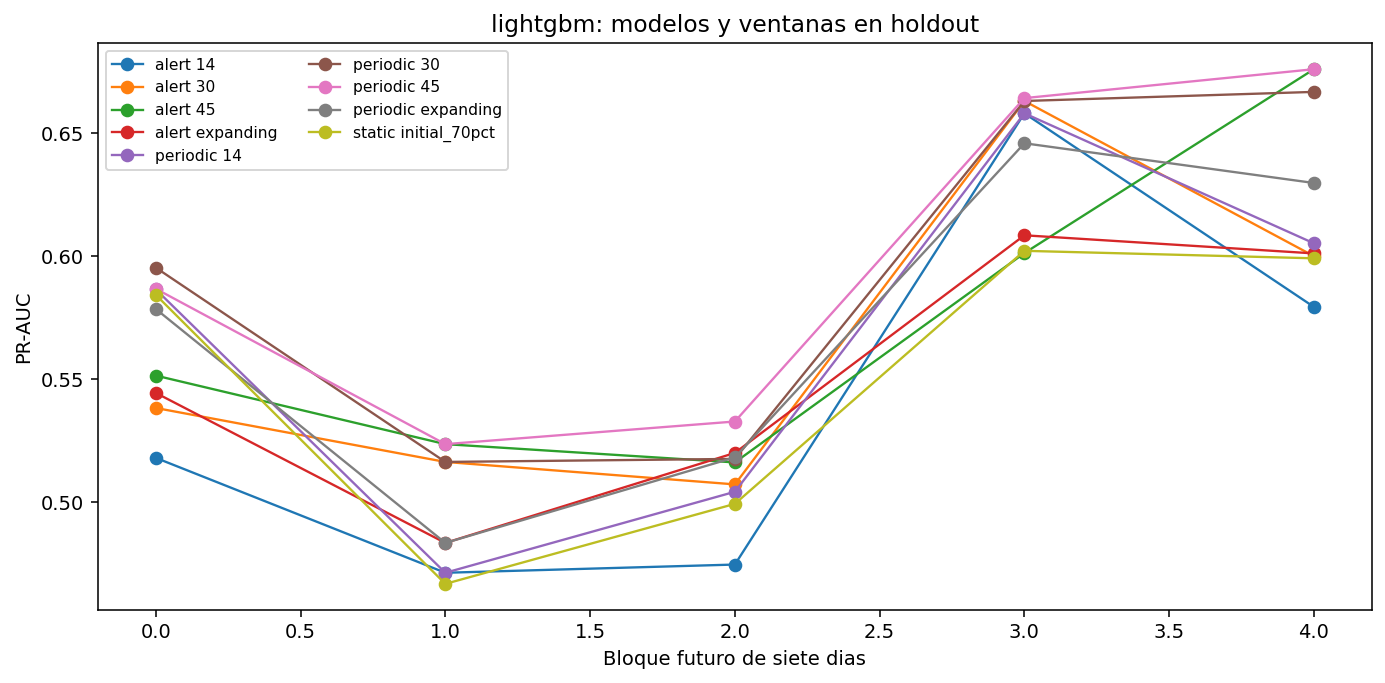

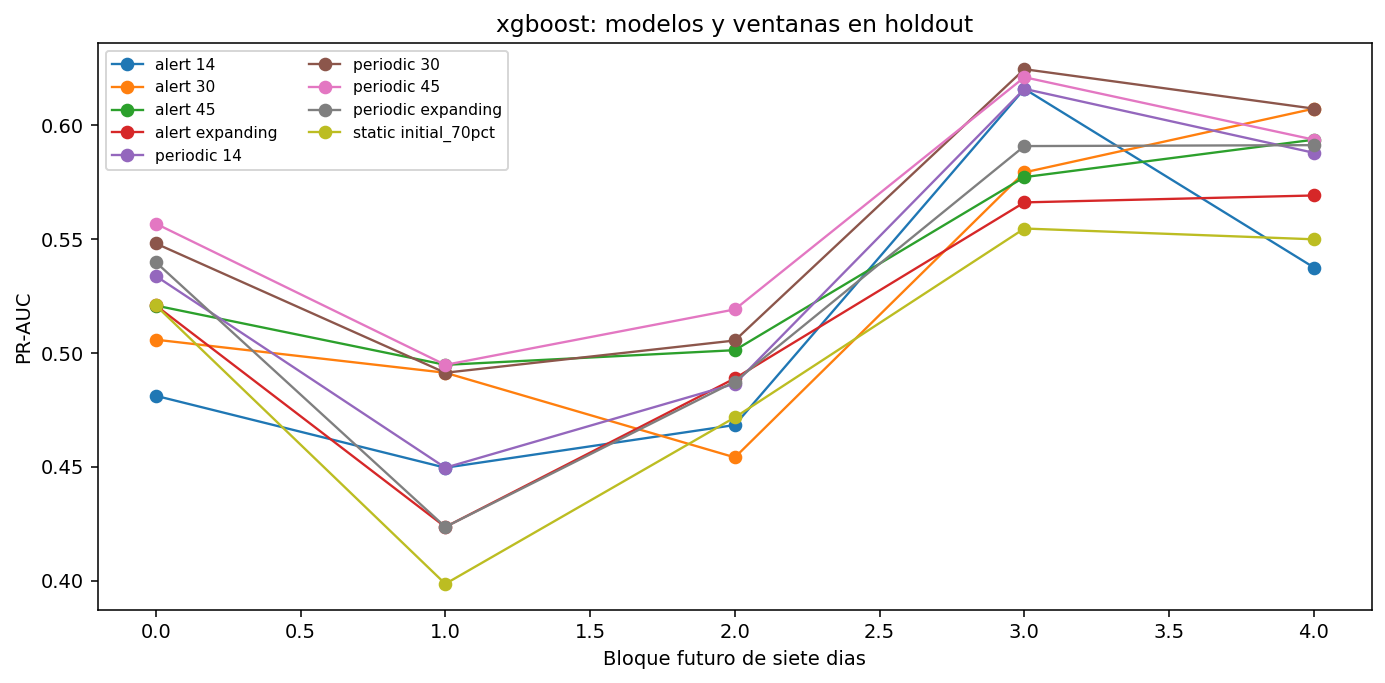

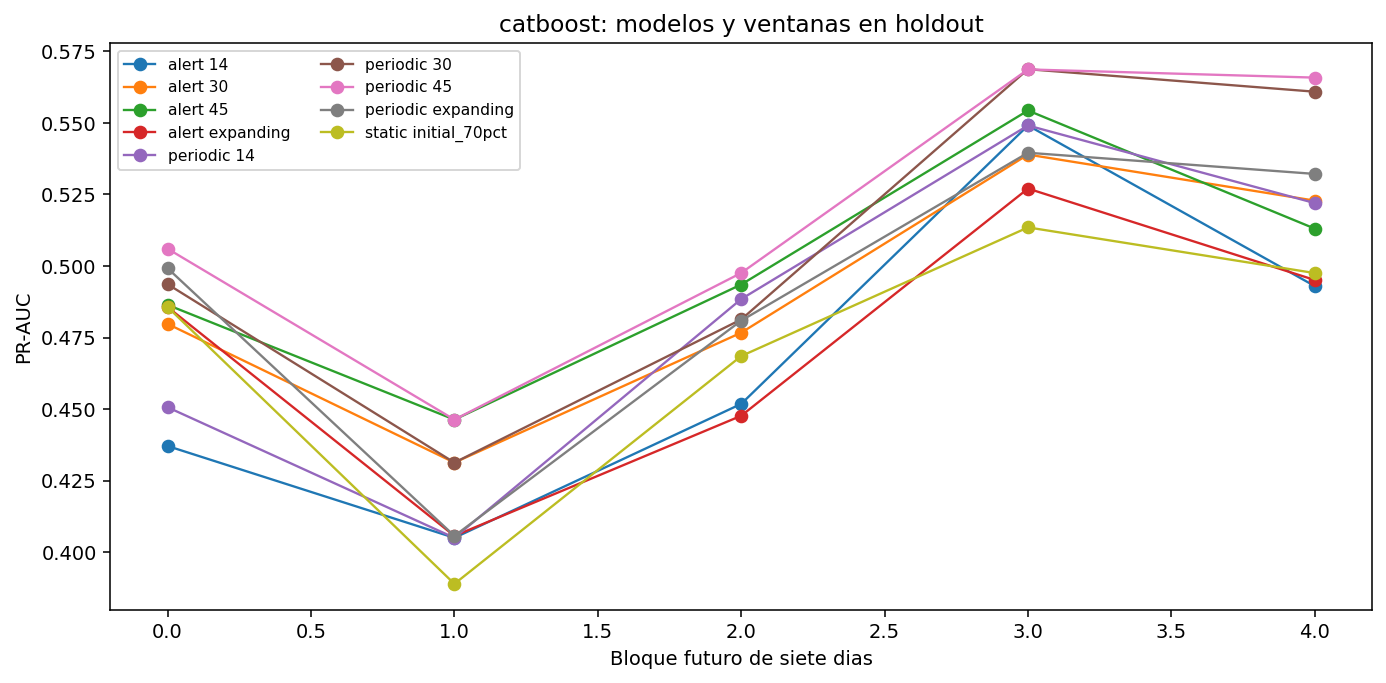

In [8]:
for name in ['01_pr_auc_lightgbm.png', '01_pr_auc_xgboost.png', '01_pr_auc_catboost.png']:
    path = output_dir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Figura pendiente:', path)

### Lectura de los resultados ejecutados
    En los cinco bloques de holdout, la media PR-AUC de LightGBM periódico de 45 días es **0.597**, frente a **0.550** del V01 estático. La alerta de 45 días alcanza **0.574** con dos actualizaciones, frente a cinco de la periódica. La ventana de 45 días también lidera dentro de XGBoost (**0.557**) y CatBoost (**0.517**). Estas medias describen ranking; una mejora de PR-AUC no garantiza menor pérdida ligada al monto.

### Balance entre desempeño y actualizaciones
El gráfico separa la posible mejora de ranking del costo de entrenar con más frecuencia. Los costos detallados, con revisión imperfecta, están en el notebook 4.

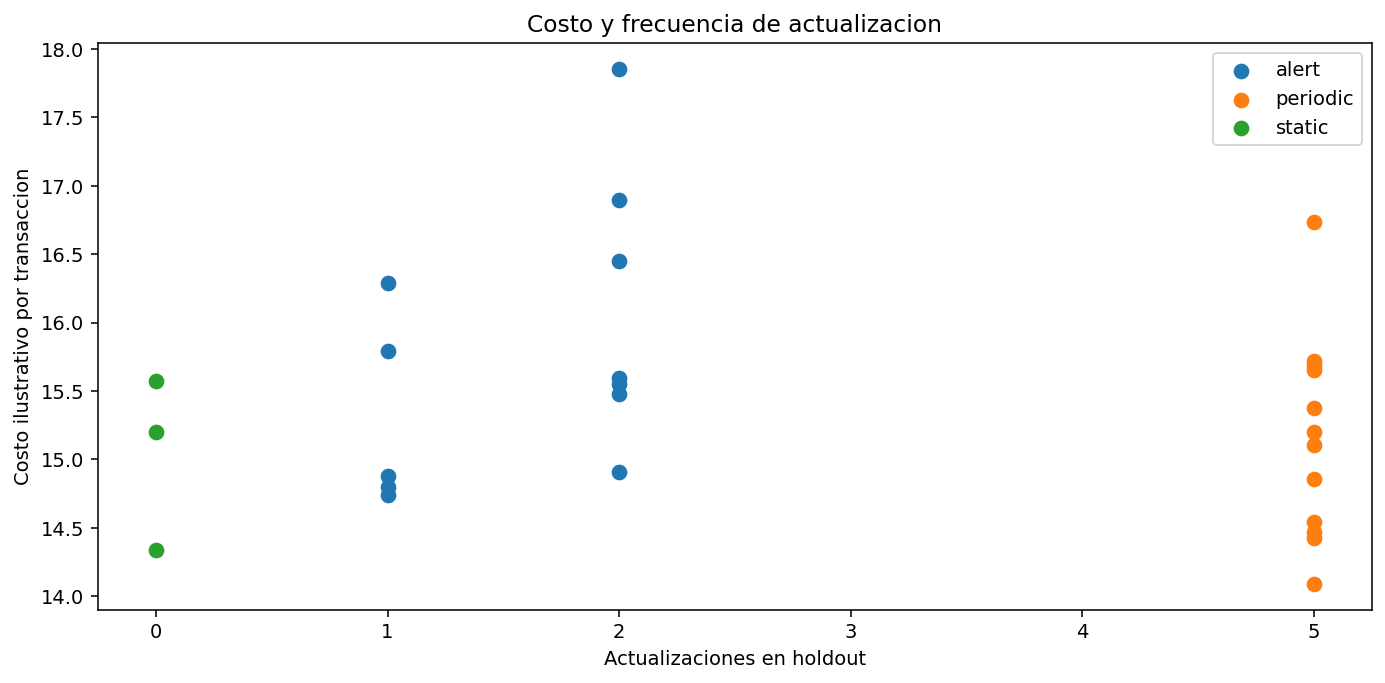

In [9]:
for name in ['02_costo_vs_actualizaciones.png']:
    path = output_dir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('Figura pendiente:', path)

### Valores auditables y comparaciones tradicionales
La tabla exacta permite rastrear PR-AUC, UID, tiempo y dispositivo sin saturar la exposición con cuadros.

In [10]:
display(pd.read_csv(output_dir / 'holdout_summary.csv').sort_values('mean_pr_auc', ascending=False).head(15)); display(pd.read_csv(output_dir / 'traditional_baselines.csv'))

,model,strategy,window_days,mean_pr_auc,mean_cost_proxy,updates,train_seconds,blocks
15,lightgbm,periodic,45,0.596580,14.470437,5,42.713763,5
14,lightgbm,periodic,30,0.591737,14.427691,5,31.197743,5
11,lightgbm,alert,45,0.573621,14.905219,2,16.583310,5
16,lightgbm,periodic,expanding,0.571093,14.090288,5,144.681644,5
13,lightgbm,periodic,14,0.564996,15.102491,5,19.316647,5
10,lightgbm,alert,30,0.564929,15.553002,2,12.708565,5
24,xgboost,periodic,45,0.557023,14.858847,5,29.333578,5
23,xgboost,periodic,30,0.555294,15.654565,5,20.664877,5
12,lightgbm,alert,expanding,0.551444,14.797476,1,26.936842,5
17,lightgbm,static,initial_70pct,0.550288,14.339369,0,0.000000,5


,model,split,rows,pr_auc,train_seconds
0,regresion_logistica,valid,88581,0.370677,221.455609
1,regresion_logistica,holdout,88581,0.169766,221.455609
2,arbol_decision,valid,88581,0.358552,19.963569
3,arbol_decision,holdout,88581,0.380621,19.963569


## Interpretación y límites
Elegir la estrategia ganadora con validación y comprobarla en holdout. La referencia V01 de LightGBM usa los scores guardados de la corrida original; los otros estáticos se ajustan con el mismo train y la misma superficie de variables. GPU y CPU pueden producir pequeñas diferencias numéricas; el archivo `fit_log.csv` documenta las caídas a CPU y la duración.